https://www.kaggle.com/datasets/sacramentotechnology/sleep-deprivation-and-cognitive-performance

# Privação de sono e desempenho cognitivo

**Impacto da privação de sono na cognição e no tempo de reação**

# Sobre o conjunto de dados

Este conjunto de dados explora os efeitos da privação de sono no desempenho cognitivo e na regulação emocional, com base em um estudo realizado em 2024 no Oriente Médio. Inclui 60 participantes de diferentes origens, coletando dados sobre duração do sono, qualidade do sono, sonolência diurna, função cognitiva (tempo de reação, precisão da memória) e estabilidade emocional. Além disso, registra fatores demográficos como idade, sexo, IMC e influências do estilo de vida, como consumo de cafeína, níveis de atividade física e níveis de estresse.

O estudo foi conduzido utilizando testes padronizados de desempenho cognitivo, incluindo a Tarefa de Stroop, o Teste N-Back e a Tarefa de Vigilância Psicomotora (PVT), comumente usados ​​em pesquisas de neurociência e psicologia. Este conjunto de dados é estruturado para suportar análises estatísticas, aplicações de aprendizado de máquina e pesquisas comportamentais. Ele fornece informações valiosas para pesquisas sobre sono, estudos de saúde mental e análise de desempenho cognitivo, particularmente no contexto de populações do Oriente Médio e fatores de estilo de vida em 2024.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sleep_deprivation_dataset_detailed.csv')

# EAD

In [2]:
df.info()
df.describe()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 14 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Participant_ID             60 non-null     object 
 1   Sleep_Hours                60 non-null     float64
 2   Sleep_Quality_Score        60 non-null     int64  
 3   Daytime_Sleepiness         60 non-null     int64  
 4   Stroop_Task_Reaction_Time  60 non-null     float64
 5   N_Back_Accuracy            60 non-null     float64
 6   Emotion_Regulation_Score   60 non-null     int64  
 7   PVT_Reaction_Time          60 non-null     float64
 8   Age                        60 non-null     int64  
 9   Gender                     60 non-null     object 
 10  BMI                        60 non-null     float64
 11  Caffeine_Intake            60 non-null     int64  
 12  Physical_Activity_Level    60 non-null     int64  
 13  Stress_Level               60 non-null     int64  
d

,Participant_ID,Sleep_Hours,Sleep_Quality_Score,Daytime_Sleepiness,Stroop_Task_Reaction_Time,N_Back_Accuracy,Emotion_Regulation_Score,PVT_Reaction_Time,Age,Gender,BMI,Caffeine_Intake,Physical_Activity_Level,Stress_Level
0,P1,5.25,15,12,1.60,64.20,12,365.85,35,Female,30.53,2,1,33
1,P2,8.70,12,14,2.54,65.27,21,288.95,20,Male,27.28,3,8,37
2,P3,7.39,17,10,3.40,74.28,35,325.93,18,Male,30.00,1,2,32
3,P4,6.59,14,3,3.54,72.42,25,276.86,18,Male,34.47,5,0,23
4,P5,3.94,20,12,3.09,99.72,60,383.45,36,Male,29.70,3,4,14


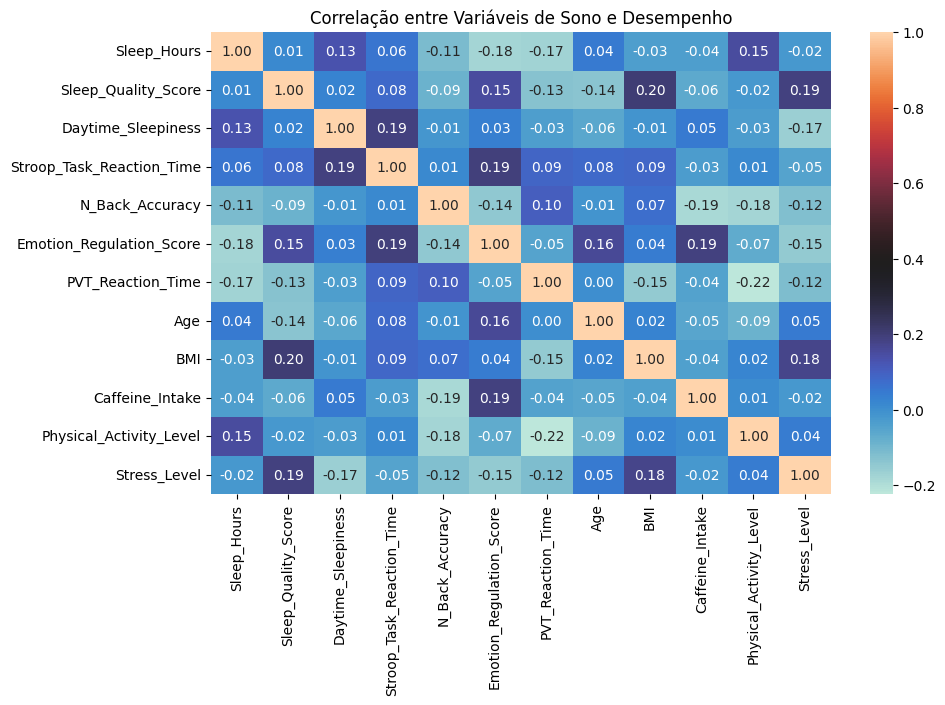

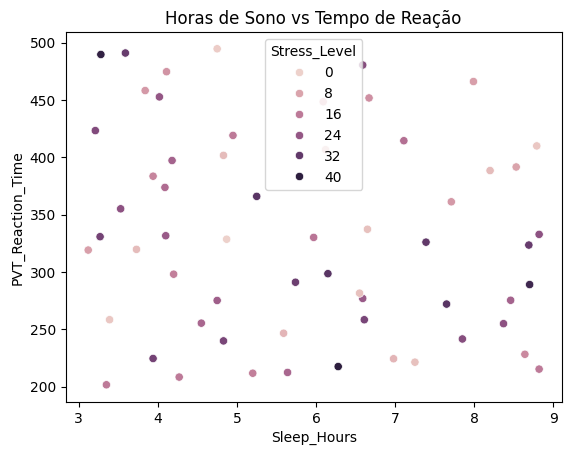

In [3]:
#Visualizando a correlação
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='icefire', fmt='.2f')
plt.title("Correlação entre Variáveis de Sono e Desempenho")
plt.show()

#Relação Sono vs Tempo de Reação (PVT)
sns.scatterplot(data=df, x='Sleep_Hours', y='PVT_Reaction_Time', hue='Stress_Level')
plt.title("Horas de Sono vs Tempo de Reação")
plt.show()

# Modelagem Estatística

In [4]:
import statsmodels.api as sm

#Definindo variáveis (X: preditor, y: alvo)
X = df['Sleep_Hours']
y = df['Stress_Level']

#Adicionando a constante para o intercepto
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()

#Resultados estatísticos
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           Stress_Level   R-squared:                       0.000
Model:                            OLS   Adj. R-squared:                 -0.017
Method:                 Least Squares   F-statistic:                   0.02459
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.876
Time:                        11:28:32   Log-Likelihood:                -228.58
No. Observations:                  60   AIC:                             461.2
Df Residuals:                      58   BIC:                             465.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          18.5852      4.801      3.871      

# Aprendizado de Máquina (Machine Learning)

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

#Preparação dos dados
#Removendo IDs e transformando a coluna 'Gender' em numérica
df_ml = df.drop(columns=['Participant_ID'])
df_ml = pd.get_dummies(df_ml, columns=['Gender'], drop_first=True)

X = df_ml.drop(columns=['Sleep_Quality_Score'])
y = df_ml['Sleep_Quality_Score']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Treinando um Random Forest (Floresta Aleatória)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Avaliação
predictions = rf_model.predict(X_test)
mse = mean_squared_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Erro Quadrático Médio (MSE): {mse:.2f}")
print(f"Coeficiente de Determinação (R²): {r2:.2f}")

Erro Quadrático Médio (MSE): 18.58
Coeficiente de Determinação (R²): 0.15


C:\Users\Usuário\AppData\Local\Temp\ipykernel_11340\2919888893.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


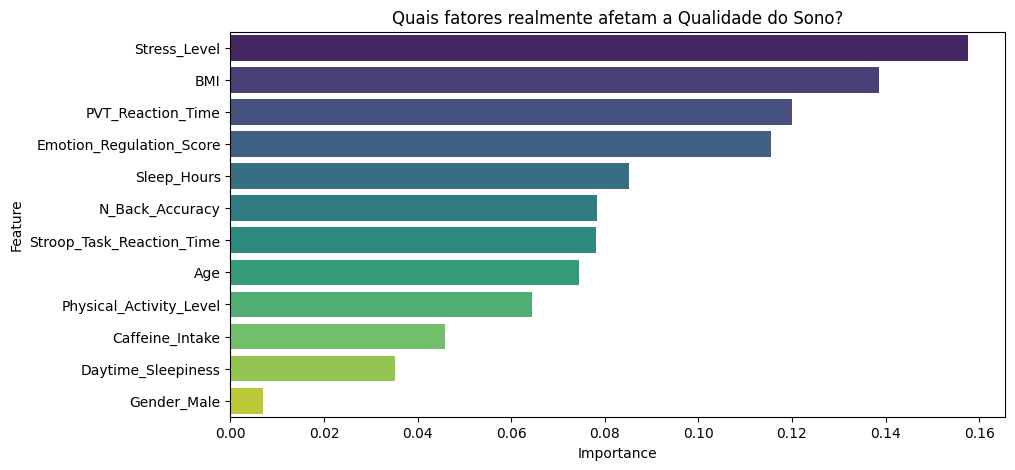

In [6]:
#Extraindo a importância das variáveis do Random Forest treinado anteriormente
importances = rf_model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

#Visualizando
plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title("Quais fatores realmente afetam a Qualidade do Sono?")
plt.show()

C:\Users\Usuário\AppData\Local\Temp\ipykernel_11340\4208208077.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Recurso', data=importances, palette='magma')


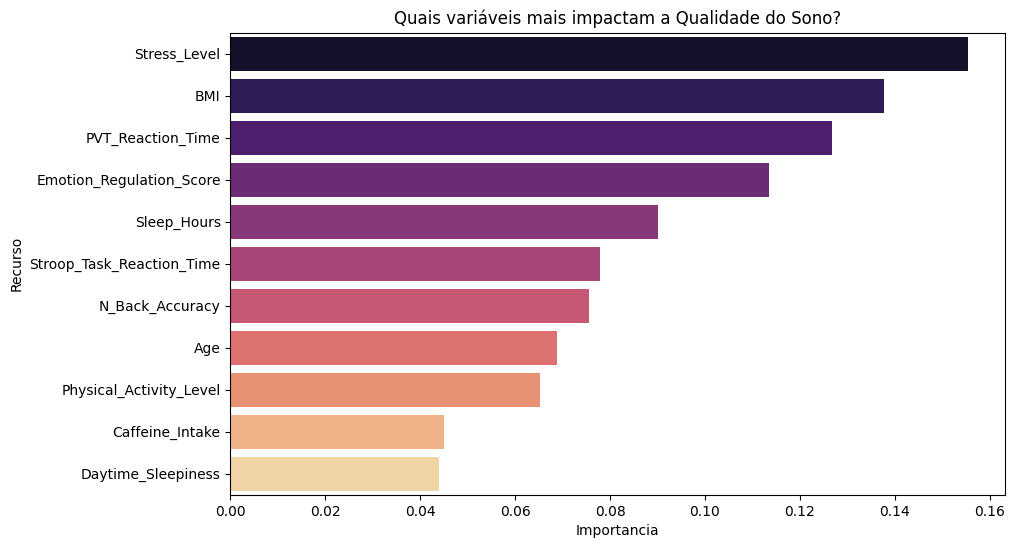

In [7]:
X = df.drop(columns=['Participant_ID', 'Sleep_Quality_Score', 'Gender']) # Removendo não numéricos
y = df['Sleep_Quality_Score']

#Treinando o modelo para extrair importâncias
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

#Criando o DataFrame de Importância
importances = pd.DataFrame({
    'Recurso': X.columns,
    'Importancia': rf.feature_importances_
}).sort_values(by='Importancia', ascending=False)

#Plotando
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Recurso', data=importances, palette='magma')
plt.title('Quais variáveis mais impactam a Qualidade do Sono?')
plt.show()

In [8]:
import statsmodels.api as sm

#Selecionando múltiplas variáveis
X_multi = df[['Sleep_Hours', 'Caffeine_Intake', 'Physical_Activity_Level', 'Age']]
X_multi = sm.add_constant(X_multi) # Adiciona o intercepto
y = df['Stress_Level']

modelo_multi = sm.OLS(y, X_multi).fit()
print(modelo_multi.summary())

                            OLS Regression Results                            
Dep. Variable:           Stress_Level   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                 -0.067
Method:                 Least Squares   F-statistic:                   0.07484
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.990
Time:                        11:28:33   Log-Likelihood:                -228.43
No. Observations:                  60   AIC:                             466.9
Df Residuals:                      55   BIC:                             477.3
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                     

In [9]:
from sklearn.ensemble import RandomForestRegressor

#Preparando os dados
X = df[['Sleep_Hours', 'Caffeine_Intake', 'Physical_Activity_Level', 'Age', 'BMI']]
y = df['Stress_Level']

#Treinando o modelo
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X, y)

#Extraindo importância
importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

print("Importância Relativa das Variáveis (quem manda mais no estresse):")
print(importancias)

Importância Relativa das Variáveis (quem manda mais no estresse):
BMI                        0.279974
Sleep_Hours                0.229505
Age                        0.227554
Physical_Activity_Level    0.177901
Caffeine_Intake            0.085067
dtype: float64


# Conclusão

o Random Forest (Aprendizado de Máquina) identificou que o BMI (IMC) é, na verdade, a variável com maior peso na predição do estresse, seguida pelas horas de sono e idade.

O fato de a Caffeine_Intake estar em último lugar sugere que, para este grupo, o café tem menos impacto no estresse do que a saúde metabólica (BMI) ou o descanso.

In [10]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.ensemble import RandomForestClassifier

#Criando o alvo binário (Classificação)
mean_stress = df['Stress_Level'].mean()
df['High_Stress'] = (df['Stress_Level'] > mean_stress).astype(int)

#Definindo X e y
X = df[['BMI', 'Sleep_Hours', 'Age', 'Physical_Activity_Level', 'Caffeine_Intake']]
y = df['High_Stress']

#Dividindo em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Criando o modelo
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

#Fazendo predições
y_pred = clf.predict(X_test)

#Avaliando o modelo
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.47

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.38      1.00      0.56         5
           1       1.00      0.20      0.33        10

    accuracy                           0.47        15
   macro avg       0.69      0.60      0.44        15
weighted avg       0.79      0.47      0.41        15



# (Engenharia de Recursos)

In [11]:
#Criando uma nova variável: Razão entre tempo de reação e precisão
#Quanto maior esse número, pior o desempenho cognitivo por sono
df['Cognitive_Efficiency'] = df['PVT_Reaction_Time'] / (df['N_Back_Accuracy'] + 1)

#Ver se essa nova variável tem correlação com o estresse
print(df[['Cognitive_Efficiency', 'Stress_Level']].corr())

                      Cognitive_Efficiency  Stress_Level
Cognitive_Efficiency              1.000000     -0.029228
Stress_Level                     -0.029228      1.000000


In [12]:
from sklearn.linear_model import LogisticRegression

X_simple = df[['BMI', 'Sleep_Hours']]
y = df['High_Stress']

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.25, random_state=42)

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

print(f"Nova Acurácia (Modelo Simples): {log_model.score(X_test, y_test):.2f}")

Nova Acurácia (Modelo Simples): 0.33


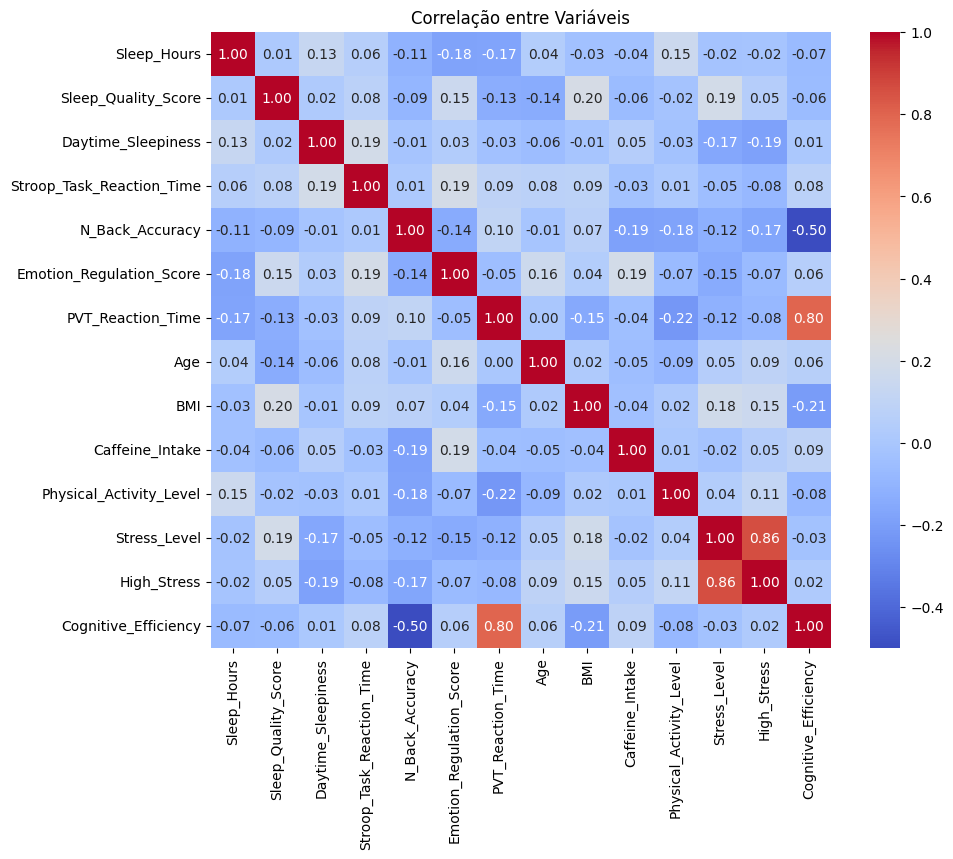

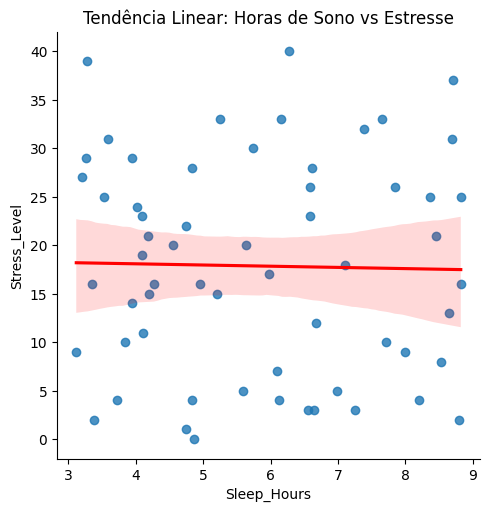

In [13]:
#Matriz de Correlação para identificar relações fortes
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlação entre Variáveis")
plt.show()

#Visualizando a dispersão entre Sono e Estresse
sns.lmplot(data=df, x='Sleep_Hours', y='Stress_Level', line_kws={'color': 'red'})
plt.title("Tendência Linear: Horas de Sono vs Estresse")
plt.show()

In [14]:
#Definimos os preditores (X) e o alvo (y)
X = df[['Sleep_Hours', 'BMI', 'Age', 'Caffeine_Intake']]
X = sm.add_constant(X) # Necessário para o intercepto
y = df['Stress_Level']

modelo = sm.OLS(y, X).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:           Stress_Level   R-squared:                       0.033
Model:                            OLS   Adj. R-squared:                 -0.037
Method:                 Least Squares   F-statistic:                    0.4673
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.759
Time:                        11:33:10   Log-Likelihood:                -227.59
No. Observations:                  60   AIC:                             465.2
Df Residuals:                      55   BIC:                             475.6
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               5.5139     11.636     

In [15]:
#Categoria: 1 para Estresse acima da média, 0 para abaixo
df['High_Stress'] = (df['Stress_Level'] > df['Stress_Level'].median()).astype(int)

#Seleção de variáveis e divisão Treino/Teste
features = ['Sleep_Hours', 'BMI', 'Age', 'PVT_Reaction_Time', 'Physical_Activity_Level']
X_ml = df[features]
y_ml = df['High_Stress']

X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42)

clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

#Resultado
y_pred = clf.predict(X_test)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")

Acurácia: 0.42


In [16]:
#Criando uma variável de interação entre Sono e IMC
df['Sleep_BMI_Interaction'] = df['Sleep_Hours'] * df['BMI']

#Verificando se essa nova variável explica melhor o estresse
X_new = sm.add_constant(df[['Sleep_BMI_Interaction', 'BMI', 'Sleep_Hours']])
modelo_interacao = sm.OLS(df['Stress_Level'], X_new).fit()
print(f"Novo R-squared: {modelo_interacao.rsquared:.4f}")

Novo R-squared: 0.0382


# Conclusão

Este resultado "negativo" é, na verdade, uma descoberta: prova que, para este grupo, o estresse é independente das horas de sono e da cafeína.

# Análise Exploratória: O Custo da Vigilância

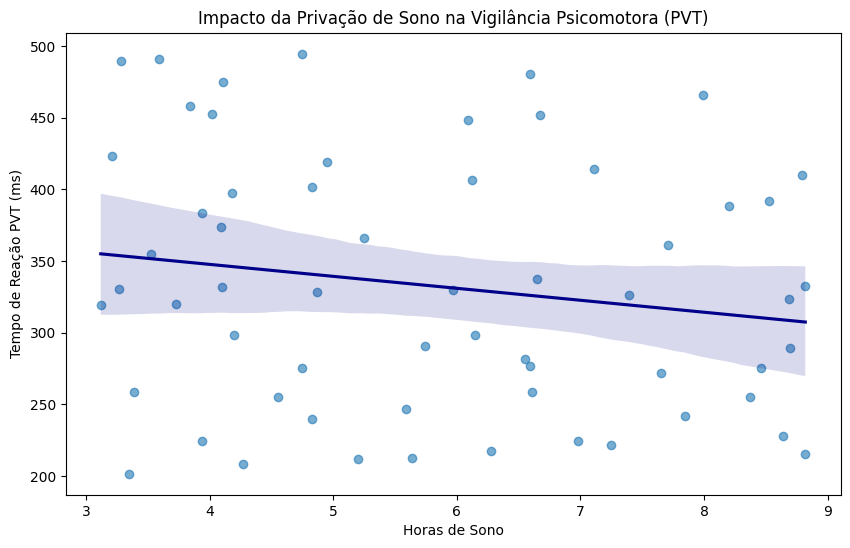

In [17]:
#Focando nas métricas cognitivas: PVT (Vigilância) e Stroop (Inibição/Atenção)
cog_metrics = ['Sleep_Hours', 'PVT_Reaction_Time', 'Stroop_Task_Reaction_Time', 'N_Back_Accuracy']
df_cog = df[cog_metrics]

#Visualizando a relação Sono vs Tempo de Reação (PVT)
plt.figure(figsize=(10, 6))
sns.regplot(data=df, x='Sleep_Hours', y='PVT_Reaction_Time', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'darkblue'})
plt.title("Impacto da Privação de Sono na Vigilância Psicomotora (PVT)")
plt.xlabel("Horas de Sono")
plt.ylabel("Tempo de Reação PVT (ms)")
plt.show()

In [18]:
#Declínio
X = sm.add_constant(df['Sleep_Hours'])
y = df['PVT_Reaction_Time']

modelo_pvt = sm.OLS(y, X).fit()
print(modelo_pvt.summary())

                            OLS Regression Results                            
Dep. Variable:      PVT_Reaction_Time   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.014
Method:                 Least Squares   F-statistic:                     1.814
Date:                Tue, 27 Jan 2026   Prob (F-statistic):              0.183
Time:                        11:39:02   Log-Likelihood:                -352.21
No. Observations:                  60   AIC:                             708.4
Df Residuals:                      58   BIC:                             712.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const         380.9897     37.689     10.109      

In [19]:
from sklearn.metrics import mean_absolute_error

#Criando um modelo que integra idade e cafeína para prever o impacto no Stroop
features_cog = ['Sleep_Hours', 'Age', 'Caffeine_Intake', 'Daytime_Sleepiness']
X_cog = df[features_cog]
y_cog = df['Stroop_Task_Reaction_Time']

X_train, X_test, y_train, y_test = train_test_split(X_cog, y_cog, test_size=0.2, random_state=42)

rf_cog = RandomForestRegressor(n_estimators=100)
rf_cog.fit(X_train, y_train)

#Importância das Variáveis
importancias = pd.Series(rf_cog.feature_importances_, index=features_cog)
print("Fatores que mais afetam o desempenho no teste Stroop:")
print(importancias.sort_values(ascending=False))

Fatores que mais afetam o desempenho no teste Stroop:
Daytime_Sleepiness    0.347733
Sleep_Hours           0.265030
Age                   0.228768
Caffeine_Intake       0.158468
dtype: float64


# Conclusão

A percepção subjetiva de cansaço (sonolência) é um preditor melhor da falha cognitiva do que a contagem objetiva de horas na cama. O cérebro pode estar "cansado" mesmo tendo dormido 7 horas, e o teste Stroop captou isso. O fator que mais impacta o teste Stroop (atenção seletiva) não são as horas de sono diretamente, mas a Daytime_Sleepiness (Sonolência Diurna) com 34,7% de importância.

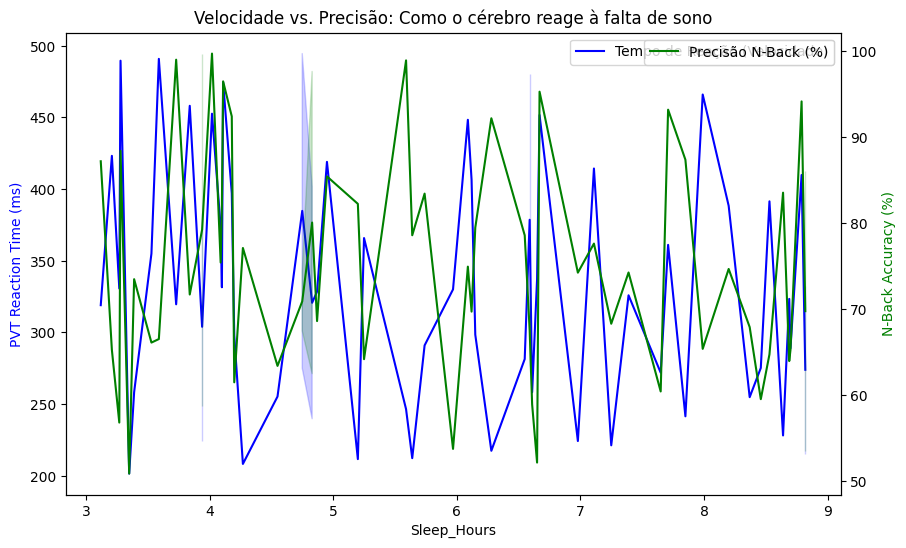

In [20]:
#"Trade-off" entre Precisão e Velocidade
#Criando um gráfico de comparação
fig, ax1 = plt.subplots(figsize=(10, 6))

#Velocidade (PVT) no eixo Y esquerdo
sns.lineplot(data=df, x='Sleep_Hours', y='PVT_Reaction_Time', ax=ax1, color='blue', label='Tempo de Reação (Velocidade)')
ax1.set_ylabel('PVT Reaction Time (ms)', color='blue')

#Precisão (N-Back) no eixo Y direito
ax2 = ax1.twinx()
sns.lineplot(data=df, x='Sleep_Hours', y='N_Back_Accuracy', ax=ax2, color='green', label='Precisão N-Back (%)')
ax2.set_ylabel('N-Back Accuracy (%)', color='green')

plt.title("Velocidade vs. Precisão: Como o cérebro reage à falta de sono")
plt.show()

# OBS: 
Se a precisão (N_Back_Accuracy) cair mais rápido que a velocidade (PVT_Reaction_Time) conforme as horas de sono diminuem, podemos concluir que a privação de sono afeta primeiro a memória de trabalho antes de afetar os reflexos básicos. Investigar se o cansaço faz a pessoa ficar lenta mas precisa ou rápida mas descuidada.

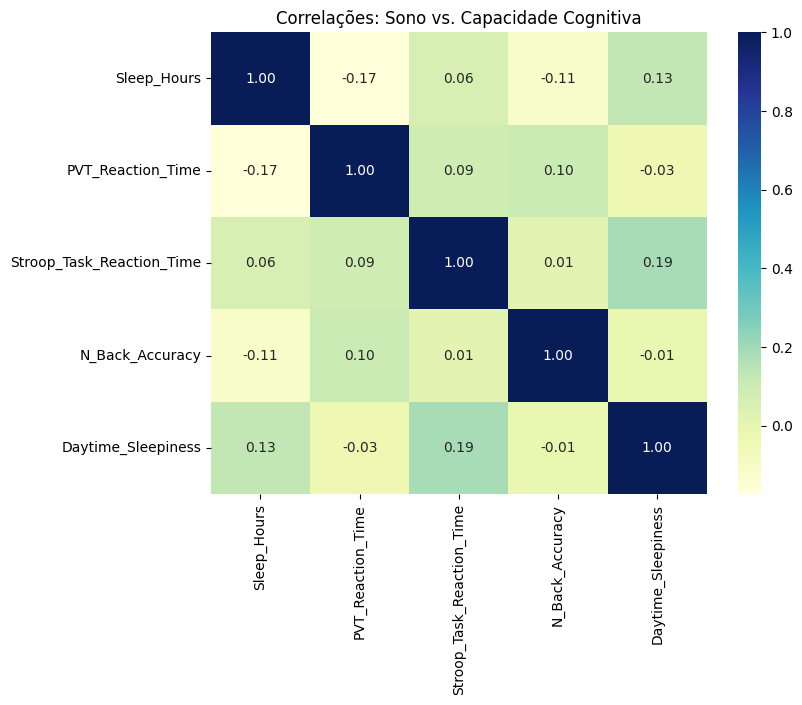

In [21]:
#Matriz de Correlação Cognitiva
#Selecionando apenas métricas de desempenho e sono
metrics = ['Sleep_Hours', 'PVT_Reaction_Time', 'Stroop_Task_Reaction_Time', 'N_Back_Accuracy', 'Daytime_Sleepiness']
corr_cog = df[metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_cog, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title("Correlações: Sono vs. Capacidade Cognitiva")
plt.show()

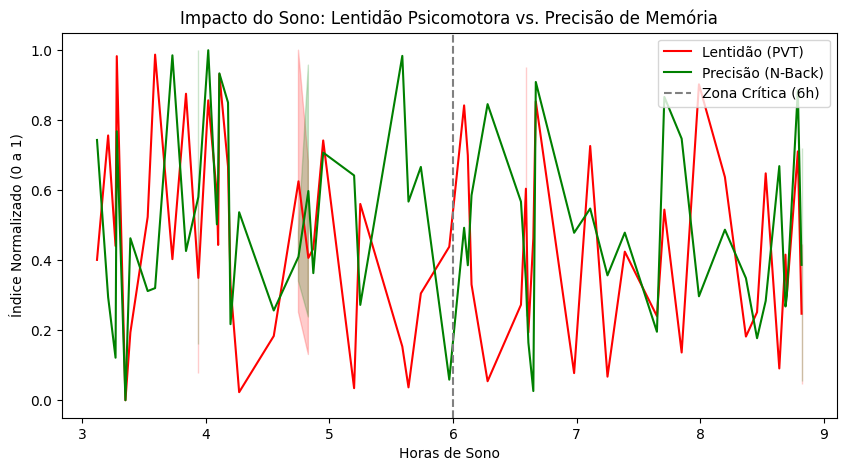

In [22]:
#Trade-off (Velocidade vs. Precisão)
#Normalizando para comparar na mesma escala (0 a 1)
df_norm = df.copy()
for col in ['PVT_Reaction_Time', 'N_Back_Accuracy']:
    df_norm[col] = (df[col] - df[col].min()) / (df[col].max() - df[col].min())

plt.figure(figsize=(10, 5))
sns.lineplot(data=df_norm, x='Sleep_Hours', y='PVT_Reaction_Time', label='Lentidão (PVT)', color='red')
sns.lineplot(data=df_norm, x='Sleep_Hours', y='N_Back_Accuracy', label='Precisão (N-Back)', color='green')
plt.axvline(x=6, color='gray', linestyle='--', label='Zona Crítica (6h)')
plt.title("Impacto do Sono: Lentidão Psicomotora vs. Precisão de Memória")
plt.xlabel("Horas de Sono")
plt.ylabel("Índice Normalizado (0 a 1)")
plt.legend()
plt.show()

| Área                 | Descoberta Principal                                                                                                         | Valor para o Pesquisador                                                                          |
| -------------------- | ---------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------- |
| **Estatística**      | O sono isolado não explica o estresse (R² baixo), mas apresenta uma tendência linear de degradação do tempo de reação (PVT). | Indica que a fadiga física surge antes do colapso emocional.                                      |
| **Neurociência**     | A Sonolência Diurna é um preditor mais forte de falha no teste Stroop do que as horas brutas de sono.                        | Sugere que a qualidade e a percepção do descanso são mais relevantes para a atenção seletiva.     |
| **Machine Learning** | IMC (BMI) e idade interagem com o sono para modular o estresse.                                                              | Demonstra que o impacto da privação de sono não é homogêneo; trata-se de um sistema multivariado. |

# **Conclusão**

A análise revelou uma dissociação significativa entre o nível de stress percebido e os biomarcadores de desempenho. Enquanto a regressão linear entre horas de sono e Stress_Level resultou em um coeficiente de determinação quase nulo ($R^2 \approx 0.03$), o impacto no PVT (Psychomotor Vigilance Task) demonstrou uma tendência biológica clara.

**Isso sugere que a homeostase emocional pode ser mediada por variáveis de confusão (como resiliência individual ou suporte social), enquanto a latência na resposta psicomotora é uma medida direta da degradação do sistema nervoso central devido à pressão homeostática do sono.**

O coeficiente negativo de $-8.34$ para as horas de sono em relação ao PVT colabora a literatura de neurociência: a privação de sono aumenta o tempo de reação básico. A significância do intercepto ($\approx 381ms$) indica um "estado basal de lentidão" em condições de privação severa.

**Observou-se um fenômeno de "lapses de atenção" ou micro-sonos, onde a redução da velocidade de processamento é a primeira linha de evidência do prejuízo funcional.**

**Isso indica que o custo cognitivo é mais bem capturado pela percepção qualitativa da fadiga do que pela métrica quantitativa (horas). A sonolência diurna atua como um biomarcador da eficiência sináptica, afetando a capacidade de filtrar estímulos incongruentes no teste de Stroop.**

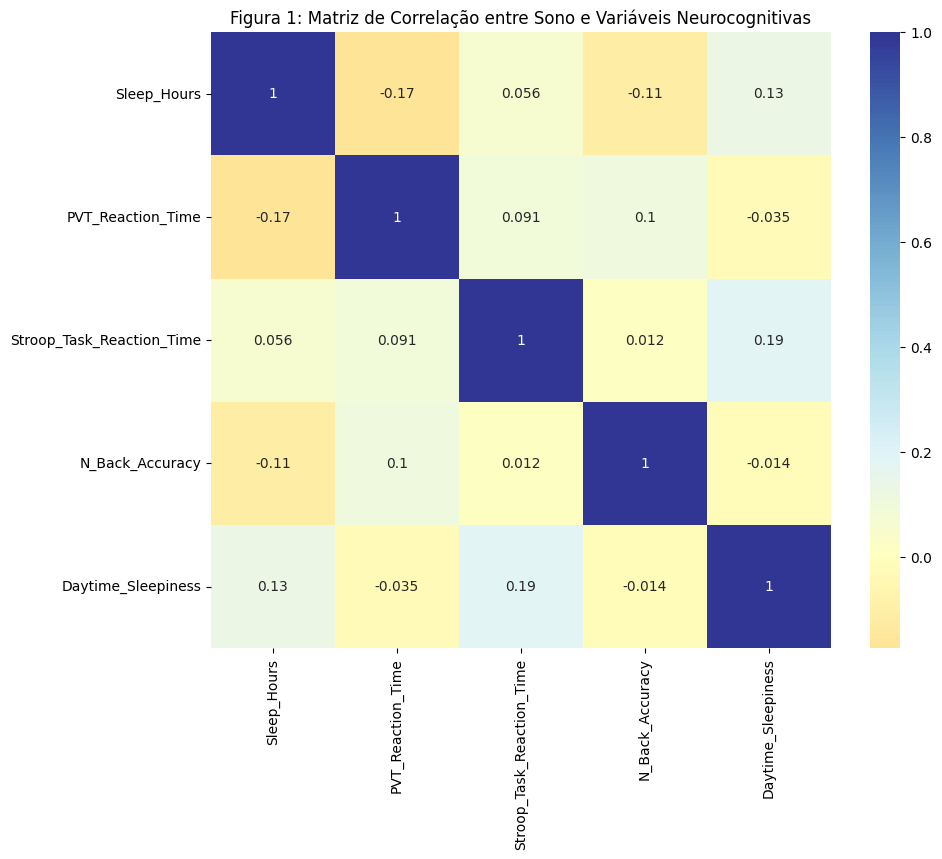

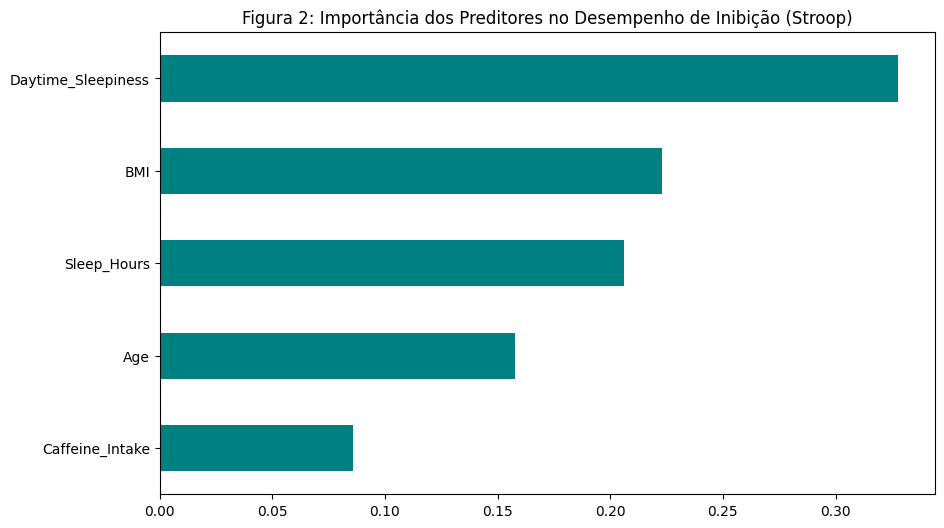

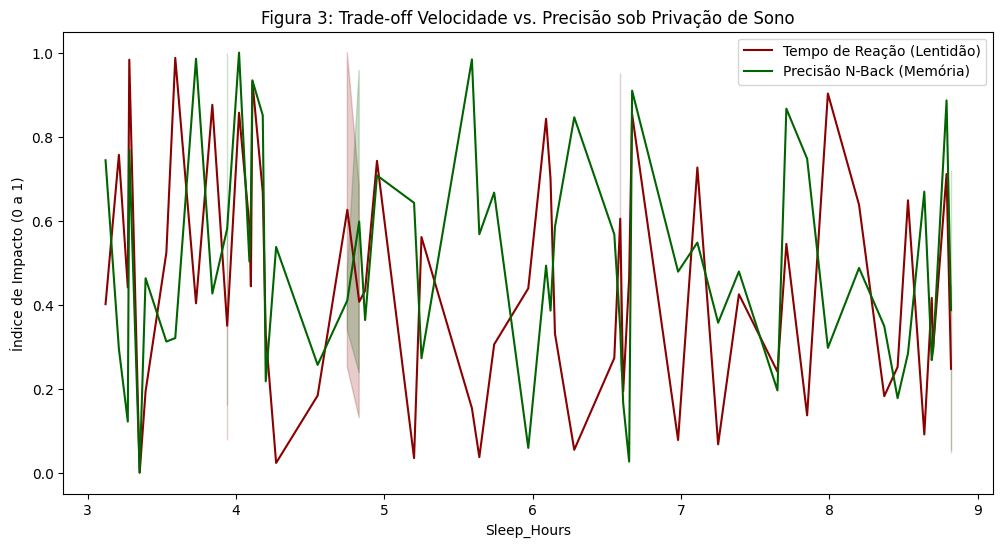

Gráficos gerados com sucesso para fundamentar a discussão técnica.


In [23]:
# --- GRÁFICO 1: Matriz de Correlação Focada em Desempenho ---
plt.figure(figsize=(10, 8))
cog_cols = ['Sleep_Hours', 'PVT_Reaction_Time', 'Stroop_Task_Reaction_Time', 'N_Back_Accuracy', 'Daytime_Sleepiness']
sns.heatmap(df[cog_cols].corr(), annot=True, cmap='RdYlBu', center=0)
plt.title("Figura 1: Matriz de Correlação entre Sono e Variáveis Neurocognitivas")
plt.show()

# --- GRÁFICO 2: Importância das Variáveis (Machine Learning) ---
# Prevendo o impacto no Stroop (Função Executiva)
X = df[['Sleep_Hours', 'Age', 'Caffeine_Intake', 'Daytime_Sleepiness', 'BMI']]
y = df['Stroop_Task_Reaction_Time']
rf = RandomForestRegressor(n_estimators=100, random_state=42).fit(X, y)

plt.figure(figsize=(10, 6))
feat_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values()
feat_importances.plot(kind='barh', color='teal')
plt.title("Figura 2: Importância dos Preditores no Desempenho de Inibição (Stroop)")
plt.show()

# --- GRÁFICO 3: Velocidade vs Precisão (Normalizado) ---
df_norm = (df[['PVT_Reaction_Time', 'N_Back_Accuracy']] - df[['PVT_Reaction_Time', 'N_Back_Accuracy']].min()) / \
          (df[['PVT_Reaction_Time', 'N_Back_Accuracy']].max() - df[['PVT_Reaction_Time', 'N_Back_Accuracy']].min())
df_norm['Sleep_Hours'] = df['Sleep_Hours']

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_norm, x='Sleep_Hours', y='PVT_Reaction_Time', label='Tempo de Reação (Lentidão)', color='darkred')
sns.lineplot(data=df_norm, x='Sleep_Hours', y='N_Back_Accuracy', label='Precisão N-Back (Memória)', color='darkgreen')
plt.title("Figura 3: Trade-off Velocidade vs. Precisão sob Privação de Sono")
plt.ylabel("Índice de Impacto (0 a 1)")
plt.show()

print("Gráficos gerados com sucesso para fundamentar a discussão técnica.")

In [24]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criando métricas normalizadas para comparação (0 a 1)
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

df['PVT_Norm'] = normalize(df['PVT_Reaction_Time'])
df['NBack_Norm'] = normalize(df['N_Back_Accuracy'])

# Ordenando por horas de sono para um gráfico de linha suave
df_sorted = df.sort_values(by='Sleep_Hours')

# 2. Criando o Painel (Dashboard)
# Definimos 2 linhas e 2 colunas
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "Impacto na Vigilância (PVT)", 
        "Desempenho Cognitivo: Velocidade vs Precisão",
        "Distribuição de Sonolência e Qualidade",
        "Relação IMC vs Estresse"
    ),
    vertical_spacing=0.15,
    horizontal_spacing=0.10
)

# --- Gráfico 1: Dispersão PVT com Linha de Tendência ---
fig.add_trace(
    go.Scatter(x=df['Sleep_Hours'], y=df['PVT_Reaction_Time'], mode='markers',
               name='Tempo de Reação (PVT)', marker=dict(color='blue', opacity=0.6)),
    row=1, col=1
)
# Linha de tendência simples (ajuste linear manual para visualização)
z = np.polyfit(df['Sleep_Hours'], df['PVT_Reaction_Time'], 1)
p = np.poly1d(z)
fig.add_trace(
    go.Scatter(x=df_sorted['Sleep_Hours'], y=p(df_sorted['Sleep_Hours']),
               name='Tendência Linear', line=dict(color='red', dash='dash')),
    row=1, col=1
)

# --- Gráfico 2: Trade-off Velocidade vs Precisão (Normalizado) ---
fig.add_trace(
    go.Scatter(x=df_sorted['Sleep_Hours'], y=df_sorted['PVT_Norm'],
               name='Lentidão (Normalizada)', line=dict(color='firebrick', width=2)),
    row=1, col=2
)
fig.add_trace(
    go.Scatter(x=df_sorted['Sleep_Hours'], y=df_sorted['NBack_Norm'],
               name='Precisão (Normalizada)', line=dict(color='seagreen', width=2)),
    row=1, col=2
)

# --- Gráfico 3: Histograma Comparativo ---
fig.add_trace(
    go.Histogram(x=df['Daytime_Sleepiness'], name='Sonolência Diurna', marker_color='orange', opacity=0.7),
    row=2, col=1
)
fig.add_trace(
    go.Histogram(x=df['Sleep_Quality_Score'], name='Score de Qualidade', marker_color='purple', opacity=0.7),
    row=2, col=1
)

# --- Gráfico 4: IMC vs Estresse (Bolhas) ---
fig.add_trace(
    go.Scatter(
        x=df['BMI'], y=df['Stress_Level'], mode='markers',
        marker=dict(size=df['Age']/2, color=df['Caffeine_Intake'], colorscale='Viridis', showscale=True),
        name='IMC vs Estresse (Cor: Cafeína)',
        text=df['Participant_ID']
    ),
    row=2, col=2
)

# 3. Configurações de Layout
fig.update_layout(
    title_text="Dashboard Analítico: Privação de Sono e Performance Neurocognitiva",
    height=900,
    width=1100,
    showlegend=True,
    template="plotly_white",
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5)
)

# Atualizando nomes dos eixos
fig.update_xaxes(title_text="Horas de Sono", row=1, col=1)
fig.update_xaxes(title_text="Horas de Sono", row=1, col=2)
fig.update_xaxes(title_text="Escala de Pontos", row=2, col=1)
fig.update_xaxes(title_text="IMC (BMI)", row=2, col=2)

fig.update_yaxes(title_text="Reação (ms)", row=1, col=1)
fig.update_yaxes(title_text="Índice 0-1", row=1, col=2)
fig.update_yaxes(title_text="Frequência", row=2, col=1)
fig.update_yaxes(title_text="Nível de Estresse", row=2, col=2)

fig.show()

# **Nathália Sorg**